In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [108]:
df = pd.read_excel('/content/Pionero_DatosVuelo.xlsx', header=1)

In [109]:
# Nos quedamos con la variable Time y todas las que estan a la derecha, o sea la segunda tabla del Excel
df = df.loc[:, 'Time':]

In [110]:
df

,Time,Altitude,Velocity,Simulation altitude,Simulation Velocity [m/s],Simulation Velocity [ft/s],Smoothing (H),Smoothing (V),Error Parachute
0,0.00,-0.000021,0.000000,0.000,0.000,0.000000,0.000000e+00,0.000000,0.000000
1,0.05,-0.000021,0.000000,0.043,0.947,3.107107,1.260000e-06,0.000000,0.000000
2,0.10,-0.000021,0.000000,0.351,3.806,12.487486,7.560000e-08,0.000000,0.000000
3,0.15,-8.933647,-8.523809,1.313,7.942,26.057702,5.360187e-01,-0.511429,0.000000
4,0.20,-2.977556,-2.857143,2.961,12.154,39.877274,3.252043e-01,-0.652171,0.000000
...,...,...,...,...,...,...,...,...,...
1582,79.10,486.015900,43.095240,4634.940,-32.446,-106.455326,4.946193e+02,-131.561060,0.369400
1583,79.15,461.848800,57.428570,4634.940,-32.446,-106.455326,4.926531e+02,-120.221682,0.959466
1584,79.20,407.536200,34.428570,4634.940,-32.446,-106.455326,4.875461e+02,-110.942667,1.445284
1585,79.25,359.330900,31.523810,4634.940,-32.446,-106.455326,4.798531e+02,-102.394678,1.528210


### Altura

Comparamos altura real con altura simulada y con altura media movil (window size=50)

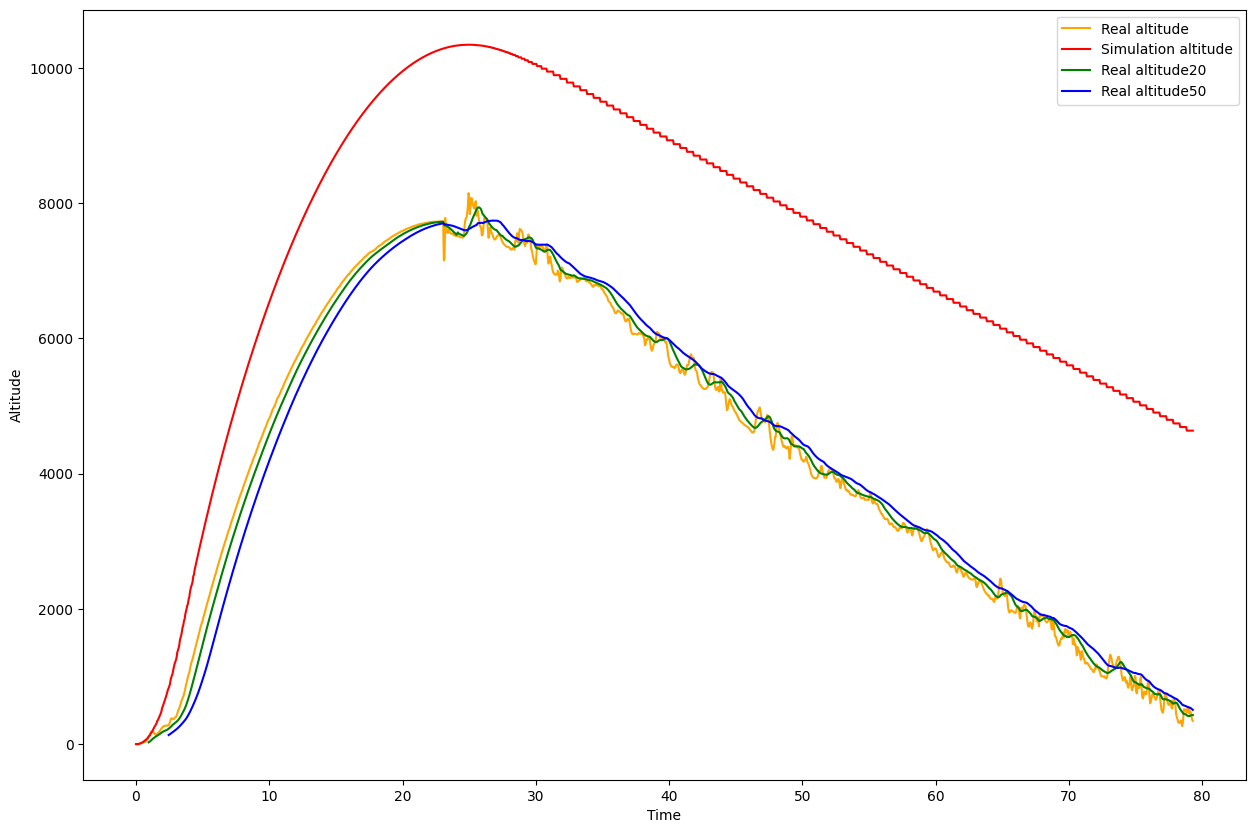

In [111]:
plt.figure(figsize=(15,10))

# Media movil 20 (hay 20 datos por segundo)
df_media_movil20 = pd.DataFrame(df['Altitude'].rolling(window=20).mean()).rename(columns={'Altitude':'Real altitude20'})

# Media movil 50
df_media_movil50 = pd.DataFrame(df['Altitude'].rolling(window=50).mean()).rename(columns={'Altitude':'Real altitude50'})

sns.lineplot(data=df, x='Time', y='Altitude', color='orange', label='Real altitude')
sns.lineplot(data=df, x='Time', y='Simulation altitude', color='red', label='Simulation altitude')
sns.lineplot(data=pd.concat([df, df_media_movil20], axis=1), x='Time', y='Real altitude20', color='green', label='Real altitude20')
sns.lineplot(data=pd.concat([df, df_media_movil50], axis=1), x='Time', y='Real altitude50', color='blue', label='Real altitude50')

plt.legend()

Seguimos con altura, solo los 10 primeros segundos

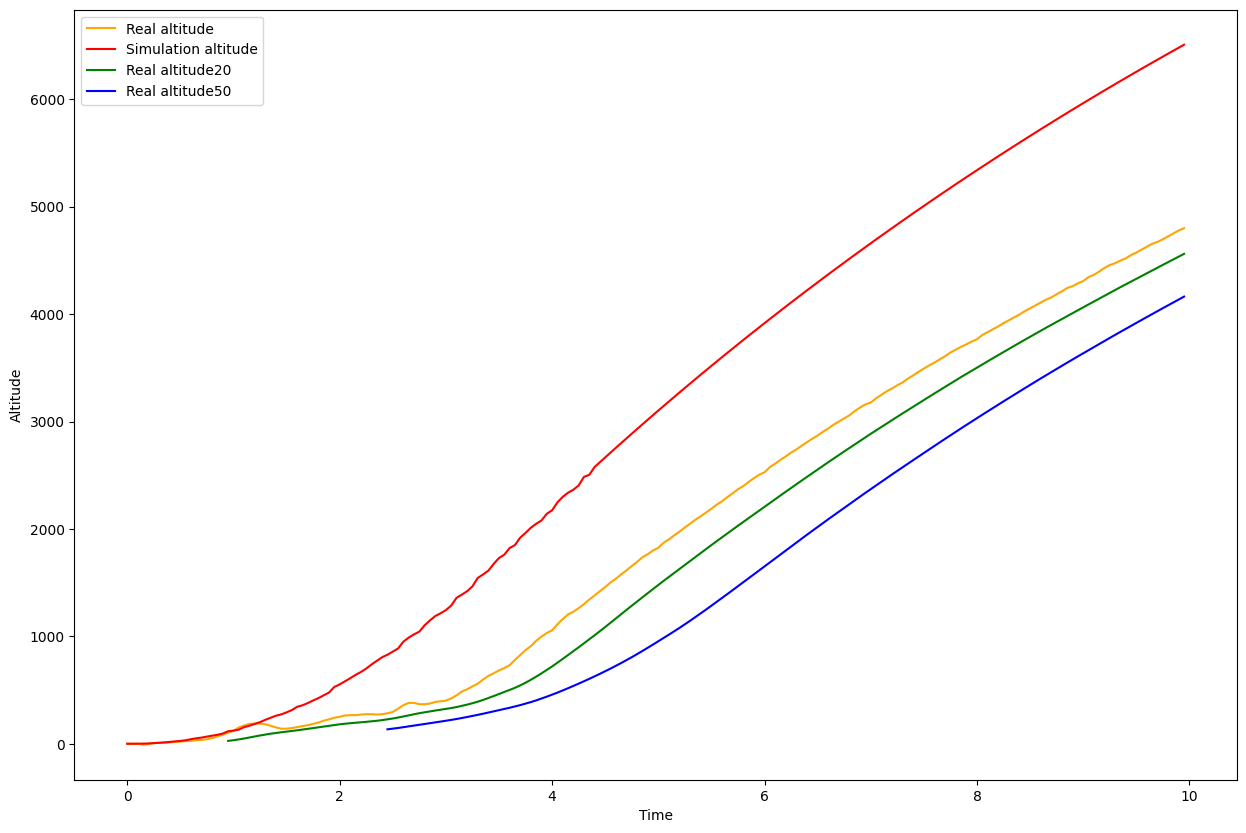

In [112]:
plt.figure(figsize=(15,10))

# Condicion Time
df_conditioned_altitude = df[df['Time']<10]

# Media movil 20 (hay 20 datos por segundo)
df_conditioned_altitude_media_movil20 = pd.DataFrame(df_conditioned_altitude['Altitude'].rolling(window=20).mean()).rename(columns={'Altitude':'Real altitude20'})

# Media movil 50
df_conditioned_altitude_media_movil50 = pd.DataFrame(df_conditioned_altitude['Altitude'].rolling(window=50).mean()).rename(columns={'Altitude':'Real altitude50'})

sns.lineplot(data=df_conditioned_altitude, x='Time', y='Altitude', color='orange', label='Real altitude')
sns.lineplot(data=df_conditioned_altitude, x='Time', y='Simulation altitude', color='red', label='Simulation altitude')
sns.lineplot(data=pd.concat([df_conditioned_altitude, df_conditioned_altitude_media_movil20], axis=1), x='Time', y='Real altitude20', color='green', label='Real altitude20')
sns.lineplot(data=pd.concat([df_conditioned_altitude, df_conditioned_altitude_media_movil50], axis=1), x='Time', y='Real altitude50', color='blue', label='Real altitude50')

plt.legend()

Calculamos la pendiente de cada punto de altura real y simulada

In [113]:
# Calculamos la pendiente de cada punto de altitud

inicio = df.loc[0,['Time','Altitude']].values
df.loc[0,'Pendiente_real'] = 0
for pos in range(1,len(df)):
  dupla = df.loc[pos, ['Time','Altitude']].values
  pendiente = (dupla[1]-inicio[1])/(dupla[0]-inicio[0])

  df.loc[pos, 'Pendiente_real'] = pendiente
  inicio = dupla

# Calculamos pendiente con diff. -> da lo mismo que arriba
# df['Pendiente_diff'] = df['Altitude'].diff()/df['Time'].diff()

In [114]:
# Calculamos la pendiente de cada punto de altitud simulada

inicio = df.loc[0,['Time','Simulation altitude']].values
df.loc[0,'Pendiente_sim'] = 0
for pos in range(1,len(df)):
  dupla = df.loc[pos, ['Time','Simulation altitude']].values
  pendiente = (dupla[1]-inicio[1])/(dupla[0]-inicio[0])

  df.loc[pos, 'Pendiente_sim'] = pendiente
  inicio = dupla

# Calculamos pendiente con diff. -> da lo mismo que arriba
# df['Pendiente_diff'] = df['Simulation altitude'].diff()/df['Time'].diff()

El maximo de altitud ocurre en el segundo 24,95. El maximo real ocurre en el mismo punto donde deberia ocurrir el maximo simulado

In [115]:
max_altura_real = df[df['Altitude']==df['Altitude'].max()]
max_altura_sim = df[df['Simulation altitude']==df['Simulation altitude'].max()]

In [116]:
(max_altura_real.index == max_altura_sim.index)

array([ True])

In [117]:
max_altura_real

,Time,Altitude,Velocity,Simulation altitude,Simulation Velocity [m/s],Simulation Velocity [ft/s],Smoothing (H),Smoothing (V),Error Parachute,Pendiente_real,Pendiente_sim
499,24.95,8145.261,591.8095,10340.809,-0.004,-0.013124,7653.699107,50.740371,0.0,3891.14,0.76


Analisis de pendientes (previo al maximo)

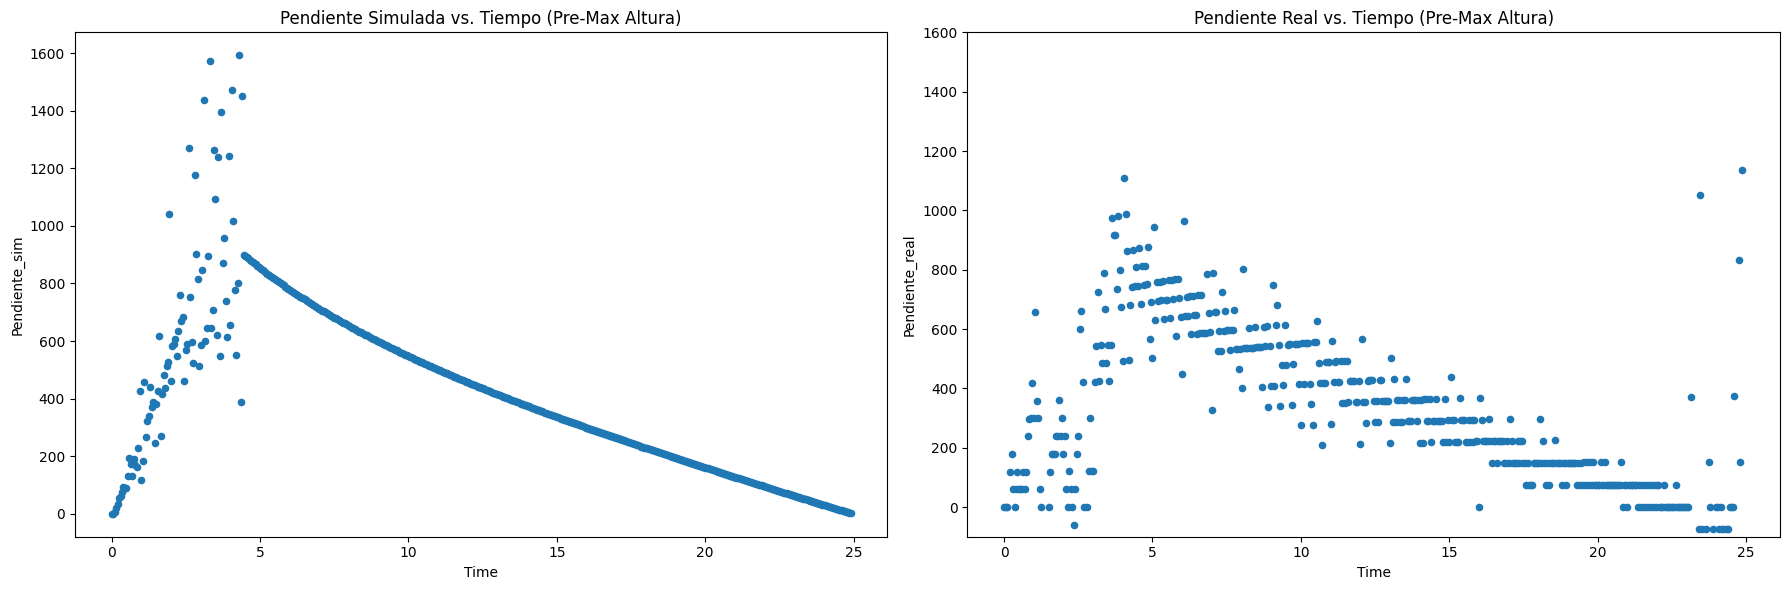

In [118]:
# Filter data to only include points before the maximum altitude
df_before_max = df[df['Time'] < max_altura_real['Time'].values[0]]

fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # 1 row, 2 columns

# Plot Pendiente_sim on the first subplot
df_before_max.plot(kind='scatter', x='Time', y='Pendiente_sim', ax=axes[0], title='Pendiente Simulada vs. Tiempo (Pre-Max Altura)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Pendiente_sim')

# Plot Pendiente_real on the second subplot
df_before_max.plot(kind='scatter', x='Time', y='Pendiente_real', ax=axes[1], title='Pendiente Real vs. Tiempo (Pre-Max Altura)')
axes[1].set_ylim(-100, 1600)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Pendiente_real')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

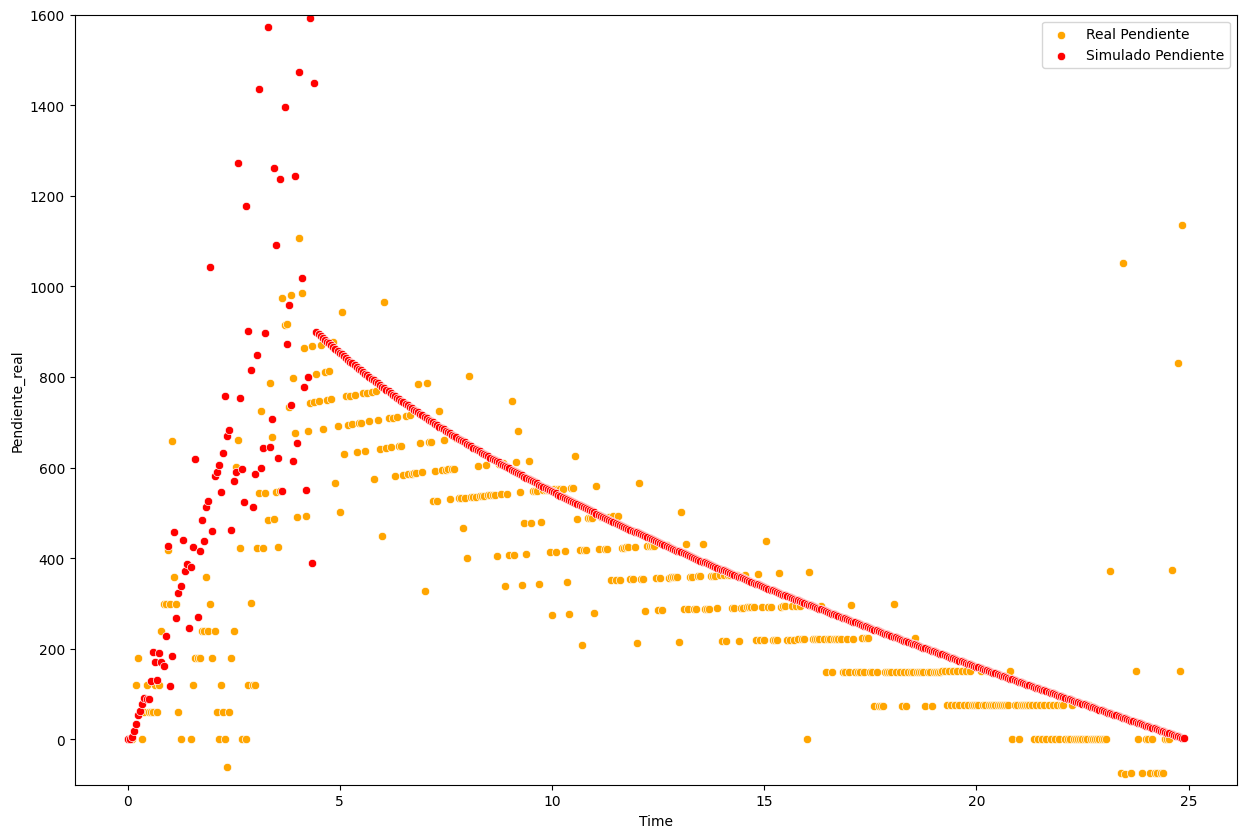

In [119]:
# Graficar las pendientes reales y simuladas en el mismo grafico
plt.figure(figsize=(15,10))

sns.scatterplot(data=df_before_max, x='Time', y='Pendiente_real', color='orange', label='Real Pendiente')
sns.scatterplot(data=df_before_max, x='Time', y='Pendiente_sim', color='red', label='Simulado Pendiente')

plt.ylim(-100, 1600)
plt.legend()

Vemos outliers (siempre antes del apogeo)

In [120]:
outliers = df_before_max[(df['Pendiente_real'] < -100) | (df['Pendiente_real'] > 1600)]
outliers_severos = outliers[abs(outliers['Pendiente_real']) > 5000]

/tmp/ipython-input-3588789934.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = df_before_max[(df['Pendiente_real'] < -100) | (df['Pendiente_real'] > 1600)]


<Axes: xlabel='Time', ylabel='Pendiente_real'>

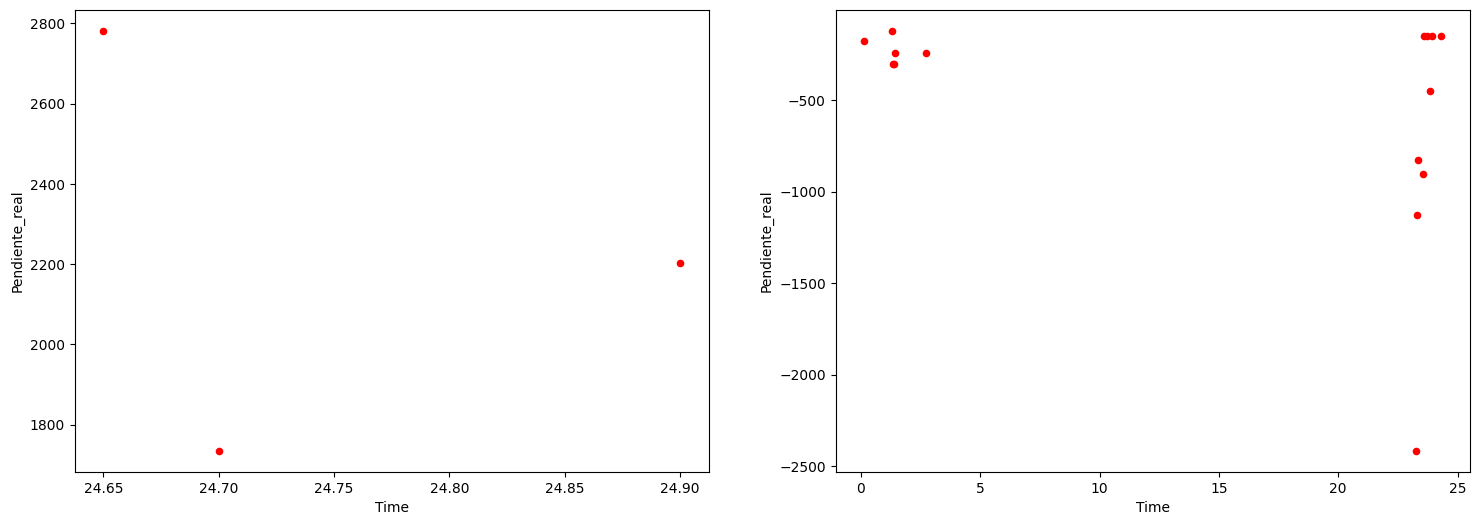

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # 1 row, 2 columns

outliers[~outliers.isin(outliers_severos)][outliers['Pendiente_real'] > 0].dropna().plot(kind='scatter', x='Time', y='Pendiente_real', ax=axes[0],color='red')

outliers[~outliers.isin(outliers_severos)][outliers['Pendiente_real'] < 0].dropna().plot(kind='scatter', x='Time', y='Pendiente_real', ax=axes[1], color='red')

In [122]:
outliers

,Time,Altitude,Velocity,Simulation altitude,Simulation Velocity [m/s],Simulation Velocity [ft/s],Smoothing (H),Smoothing (V),Error Parachute,Pendiente_real,Pendiente_sim
3,0.15,-8.933647,-8.523809,1.313,7.942,26.057702,0.536019,-0.511429,0.0,-178.67252,19.24
26,1.30,182.178200,167.904800,222.999,111.074,364.433794,77.559118,73.945918,0.0,-119.80600,439.82
27,1.35,167.208300,150.809500,241.596,115.658,379.473898,82.938068,78.557733,0.0,-299.39800,371.94
28,1.40,152.245000,136.571400,260.944,120.242,394.514002,87.096484,82.038553,0.0,-299.26600,386.96
29,1.45,140.278500,122.333300,273.255,123.072,403.799232,90.287405,84.456238,0.0,-239.33000,246.22
55,2.75,368.365400,185.904800,1044.327,237.601,779.568881,247.055963,132.645918,0.0,-240.93200,524.68
462,23.10,7150.825000,-541.619000,10286.965,17.866,58.618346,7676.706348,2.942447,0.0,-11525.70000,59.42
464,23.20,7780.024000,57.619050,10292.666,16.885,55.399685,7654.291750,-23.493827,0.0,12213.04000,56.22
465,23.25,7659.209000,-57.428570,10295.395,16.395,53.791995,7654.586785,-25.529911,0.0,-2416.30000,54.58
466,23.30,7602.736000,-114.809500,10298.044,15.905,52.184305,7651.475738,-30.886686,0.0,-1129.46000,52.98


In [123]:
outliers_severos

,Time,Altitude,Velocity,Simulation altitude,Simulation Velocity [m/s],Simulation Velocity [ft/s],Smoothing (H),Smoothing (V),Error Parachute,Pendiente_real,Pendiente_sim
462,23.1,7150.825,-541.61900,10286.965,17.866,58.618346,7676.706348,2.942447,0.0,-11525.70,59.42
464,23.2,7780.024,57.61905,10292.666,16.885,55.399685,7654.291750,-23.493827,0.0,12213.04,56.22


### Velocidad

Vemos en general

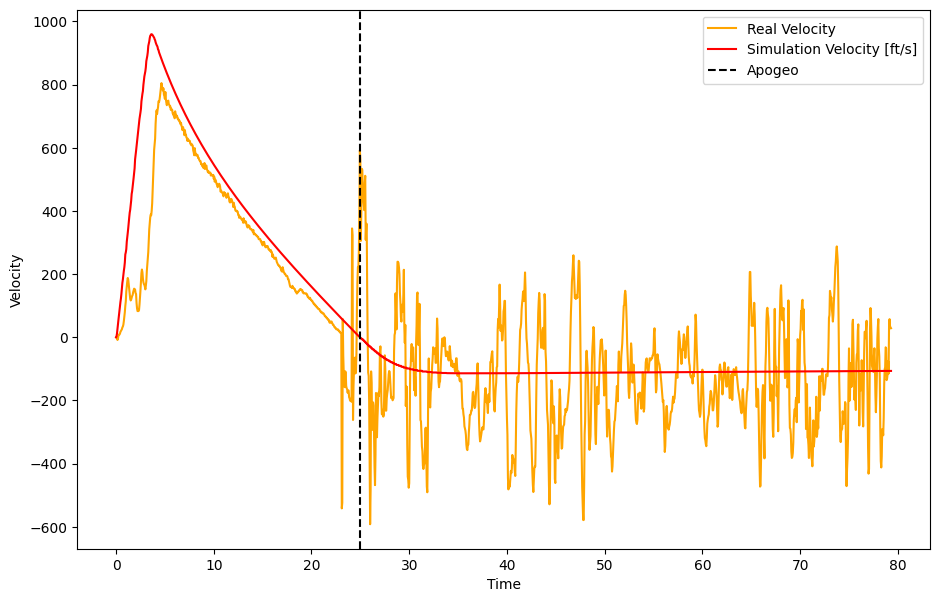

In [124]:
plt.figure(figsize=(11,7))

# # Media movil 20 (hay 20 datos por segundo)
# df_MM_vel20 = pd.DataFrame(df['Velocity'].rolling(window=20).mean()).rename(columns={'Velocity':'Real Velocity20'})

# Media movil 50
df_MM_vel50 = pd.DataFrame(df['Velocity'].rolling(window=50).mean()).rename(columns={'Velocity':'Real Velocity50'})

sns.lineplot(data=df, x='Time', y='Velocity', color='orange', label='Real Velocity')
sns.lineplot(data=df, x='Time', y='Simulation Velocity [ft/s]', color='red', label='Simulation Velocity [ft/s]')
# sns.lineplot(data=pd.concat([df, df_MM_vel20], axis=1), x='Time', y='Real Velocity20', color='green', label='Real Velocity20')
# sns.lineplot(data=pd.concat([df, df_MM_vel50], axis=1), x='Time', y='Real Velocity50', color='blue', label='Real Velocity50')

plt.axvline(x=max_altura_real['Time'].values[0], color='black', linestyle='--', label='Apogeo')

plt.legend()

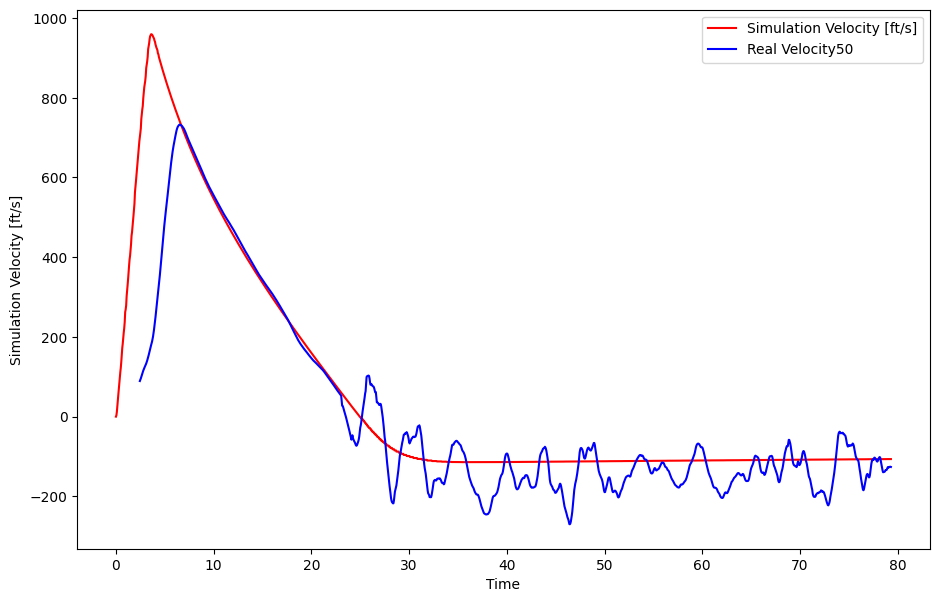

In [125]:
plt.figure(figsize=(11,7))

# # Media movil 20 (hay 20 datos por segundo)
# df_MM_vel20 = pd.DataFrame(df['Velocity'].rolling(window=20).mean()).rename(columns={'Velocity':'Real Velocity20'})

# Media movil 50
df_MM_vel50 = pd.DataFrame(df['Velocity'].rolling(window=50).mean()).rename(columns={'Velocity':'Real Velocity50'})

# sns.lineplot(data=df, x='Time', y='Velocity', color='orange', label='Real Velocity')
sns.lineplot(data=df, x='Time', y='Simulation Velocity [ft/s]', color='red', label='Simulation Velocity [ft/s]')
# sns.lineplot(data=pd.concat([df, df_MM_vel20], axis=1), x='Time', y='Real Velocity20', color='green', label='Real Velocity20')
sns.lineplot(data=pd.concat([df, df_MM_vel50], axis=1), x='Time', y='Real Velocity50', color='blue', label='Real Velocity50')

plt.legend()

Comparamos altitud y velocidad mirando el mismo eje x 'Tiempo'

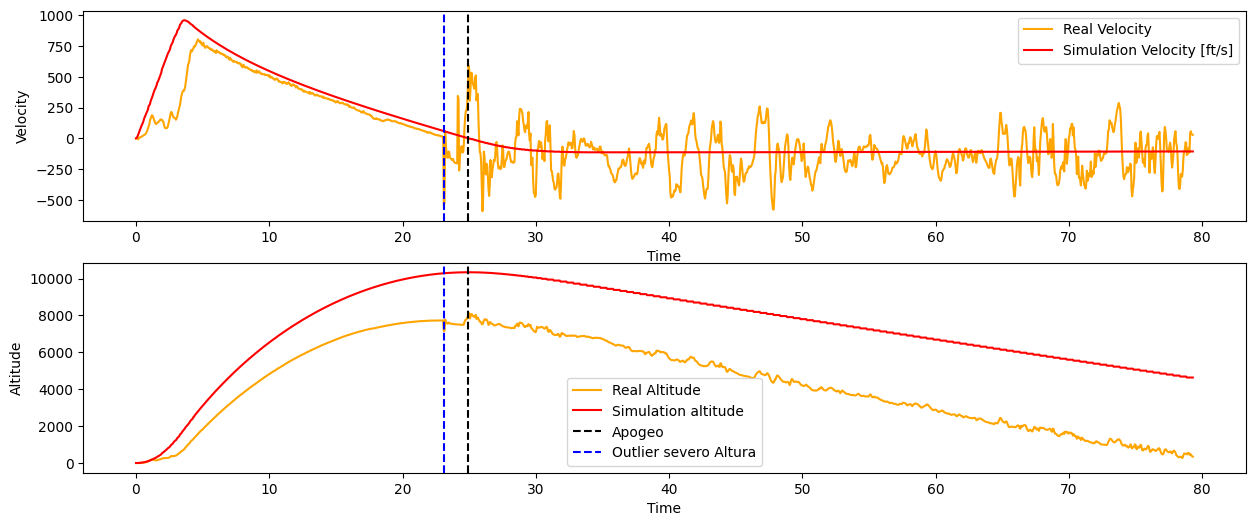

In [126]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6)) # 2 rows, 1 column

# Estas dos lineas van en el grafico superior
sns.lineplot(data=df, x='Time', y='Velocity', ax=axes[0], color='orange', label='Real Velocity')
sns.lineplot(data=df, x='Time', y='Simulation Velocity [ft/s]', ax=axes[0], color='red', label='Simulation Velocity [ft/s]')

# Estas dos lineas van en el grafico inferior
sns.lineplot(data=df, x='Time', y='Altitude', ax=axes[1], color='orange', label='Real Altitude')
sns.lineplot(data=df, x='Time', y='Simulation altitude', ax=axes[1], color='red', label='Simulation altitude')

# Plotting max value
axes[0].axvline(x=max_altura_real['Time'].values[0], color='black', linestyle='--', label='Apogeo')
axes[1].axvline(x=max_altura_real['Time'].values[0], color='black', linestyle='--', label='Apogeo')

# Plotting sever outlier
axes[0].axvline(x=outliers_severos.iloc[0,:]['Time'], color='blue', linestyle='--', label='Outlier severo Altura')
axes[1].axvline(x=outliers_severos.iloc[0,:]['Time'], color='blue', linestyle='--', label='Outlier severo Altura')


plt.legend()

Calculamos pendientes

In [127]:
# Calculamos la pendiente de cada punto de altitud

inicio = df.loc[0,['Time','Velocity']].values
df.loc[0,'Pendiente_Velocity_real'] = 0
for pos in range(1,len(df)):
  dupla = df.loc[pos, ['Time','Velocity']].values
  pendiente = (dupla[1]-inicio[1])/(dupla[0]-inicio[0])

  df.loc[pos, 'Pendiente_Velocity_real'] = pendiente
  inicio = dupla

# Calculamos pendiente con diff. -> da lo mismo que arriba
# df['Pendiente_diff'] = df['Velocity'].diff()/df['Time'].diff()

In [128]:
# Calculamos la pendiente de cada punto de altitud

inicio = df.loc[0,['Time','Simulation Velocity [ft/s]']].values
df.loc[0,'Pendiente_Velocity_sim'] = 0
for pos in range(1,len(df)):
  dupla = df.loc[pos, ['Time','Simulation Velocity [ft/s]']].values
  pendiente = (dupla[1]-inicio[1])/(dupla[0]-inicio[0])

  df.loc[pos, 'Pendiente_Velocity_sim'] = pendiente
  inicio = dupla

# Calculamos pendiente con diff. -> da lo mismo que arriba
# df['Pendiente_diff_Vel_sim'] = df['Simulation Velocity [ft/s]'].diff()/df['Time'].diff()

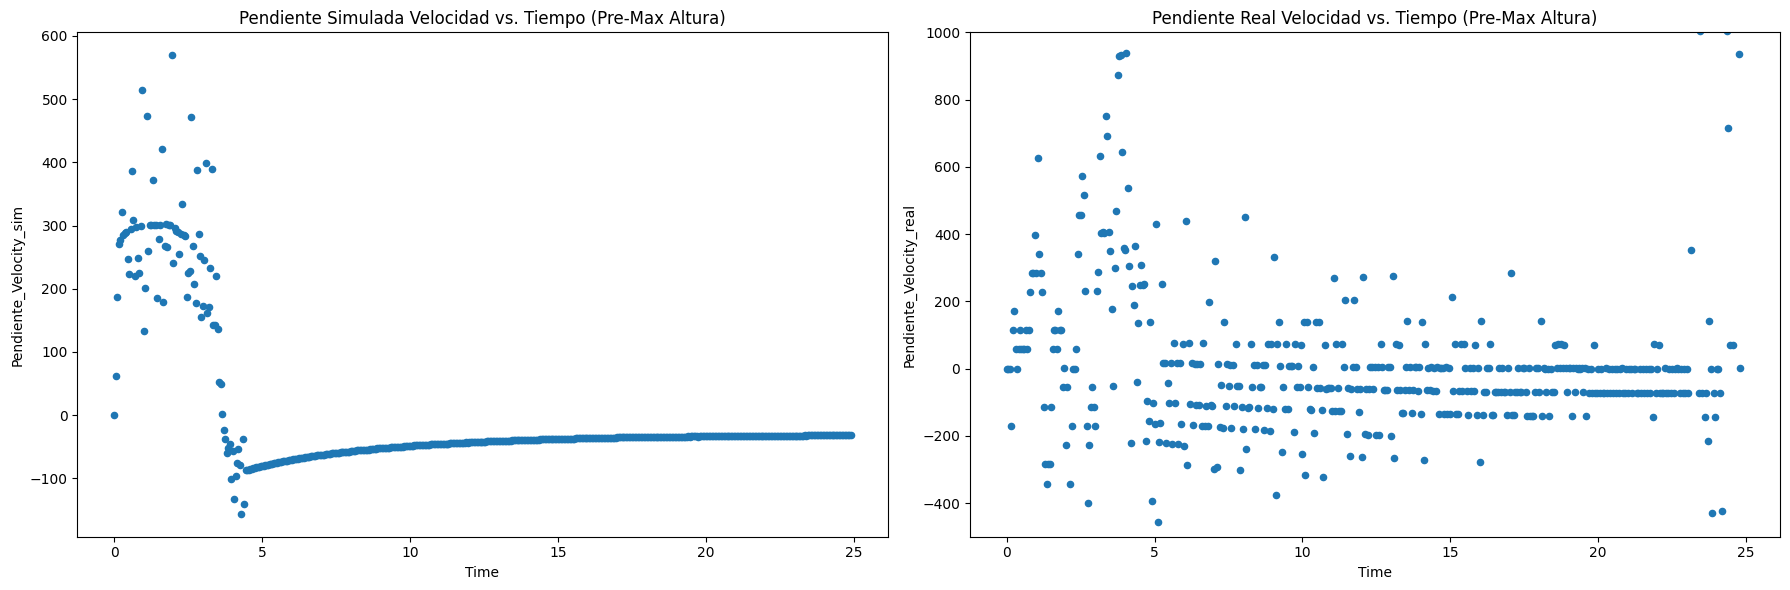

In [129]:
# Filter data to only include points before the maximum altitude
df_before_max = df[df['Time'] < max_altura_real['Time'].values[0]]

fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # 1 row, 2 columns

# Plot Pendiente_sim on the first subplot
df_before_max.plot(kind='scatter', x='Time', y='Pendiente_Velocity_sim', ax=axes[0], title='Pendiente Simulada Velocidad vs. Tiempo (Pre-Max Altura)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Pendiente_Velocity_sim')

# Plot Pendiente_real on the second subplot
df_before_max.plot(kind='scatter', x='Time', y='Pendiente_Velocity_real', ax=axes[1], title='Pendiente Real Velocidad vs. Tiempo (Pre-Max Altura)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Pendiente_Velocity_real')
axes[1].set_ylim(-500, 1000)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

In [130]:
int(max_altura_real['Time'].values[0]+1)

25

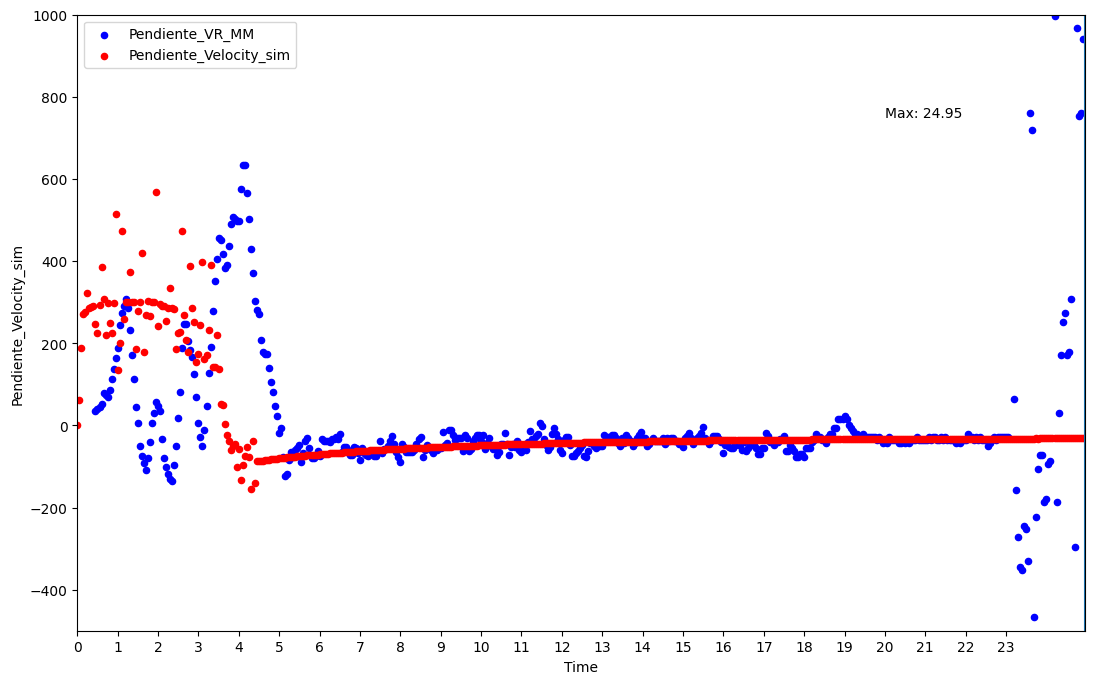

In [131]:
df['Pendiente_VR_MM'] = df['Pendiente_Velocity_real'].rolling(window=10).mean()

fig, ax = plt.subplots(figsize=(13,8))
df.plot(kind='scatter', x='Time', y='Pendiente_VR_MM', ax=ax, label='Pendiente_VR_MM', color='blue')
df.plot(kind='scatter', x='Time', y='Pendiente_Velocity_sim', ax=ax, label='Pendiente_Velocity_sim', color='red')

plt.xticks(list(range(0,int(max_altura_real['Time'].values[0]),1)))
plt.xlim(0,max_altura_real['Time'].values[0])
plt.ylim(-500, 1000)
plt.text(x=20, y=750, s=f'Max: {max_altura_real['Time'].values[0]}')
plt.axvline(x=max_altura_real['Time'].values[0])

In [132]:
df_before_max[(df['Pendiente_VR_MM'] < -500) | (df['Pendiente_VR_MM'] > 1000)]

/tmp/ipython-input-630634556.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_before_max[(df['Pendiente_VR_MM'] < -500) | (df['Pendiente_VR_MM'] > 1000)]


,Time,Altitude,Velocity,Simulation altitude,Simulation Velocity [m/s],Simulation Velocity [ft/s],Smoothing (H),Smoothing (V),Error Parachute,Pendiente_real,Pendiente_sim,Pendiente_Velocity_real,Pendiente_Velocity_sim
462,23.10,7150.825,-541.61900,10286.965,17.866,58.618346,7676.706348,2.942447,0.0,-11525.70,59.42,-11048.5704,-32.21942
463,23.15,7169.372,-523.95240,10289.855,17.375,57.007375,7646.266287,-28.671244,0.0,370.94,57.80,353.3320,-32.21942
483,24.15,7512.586,344.66670,10330.839,7.634,25.047154,7577.643379,-94.299259,0.0,0.00,25.84,10977.1440,-31.69446
493,24.65,7647.907,89.57143,10339.418,2.837,9.308197,7549.413685,-74.532887,0.0,2781.42,10.08,2791.4286,-31.23512


### Otros

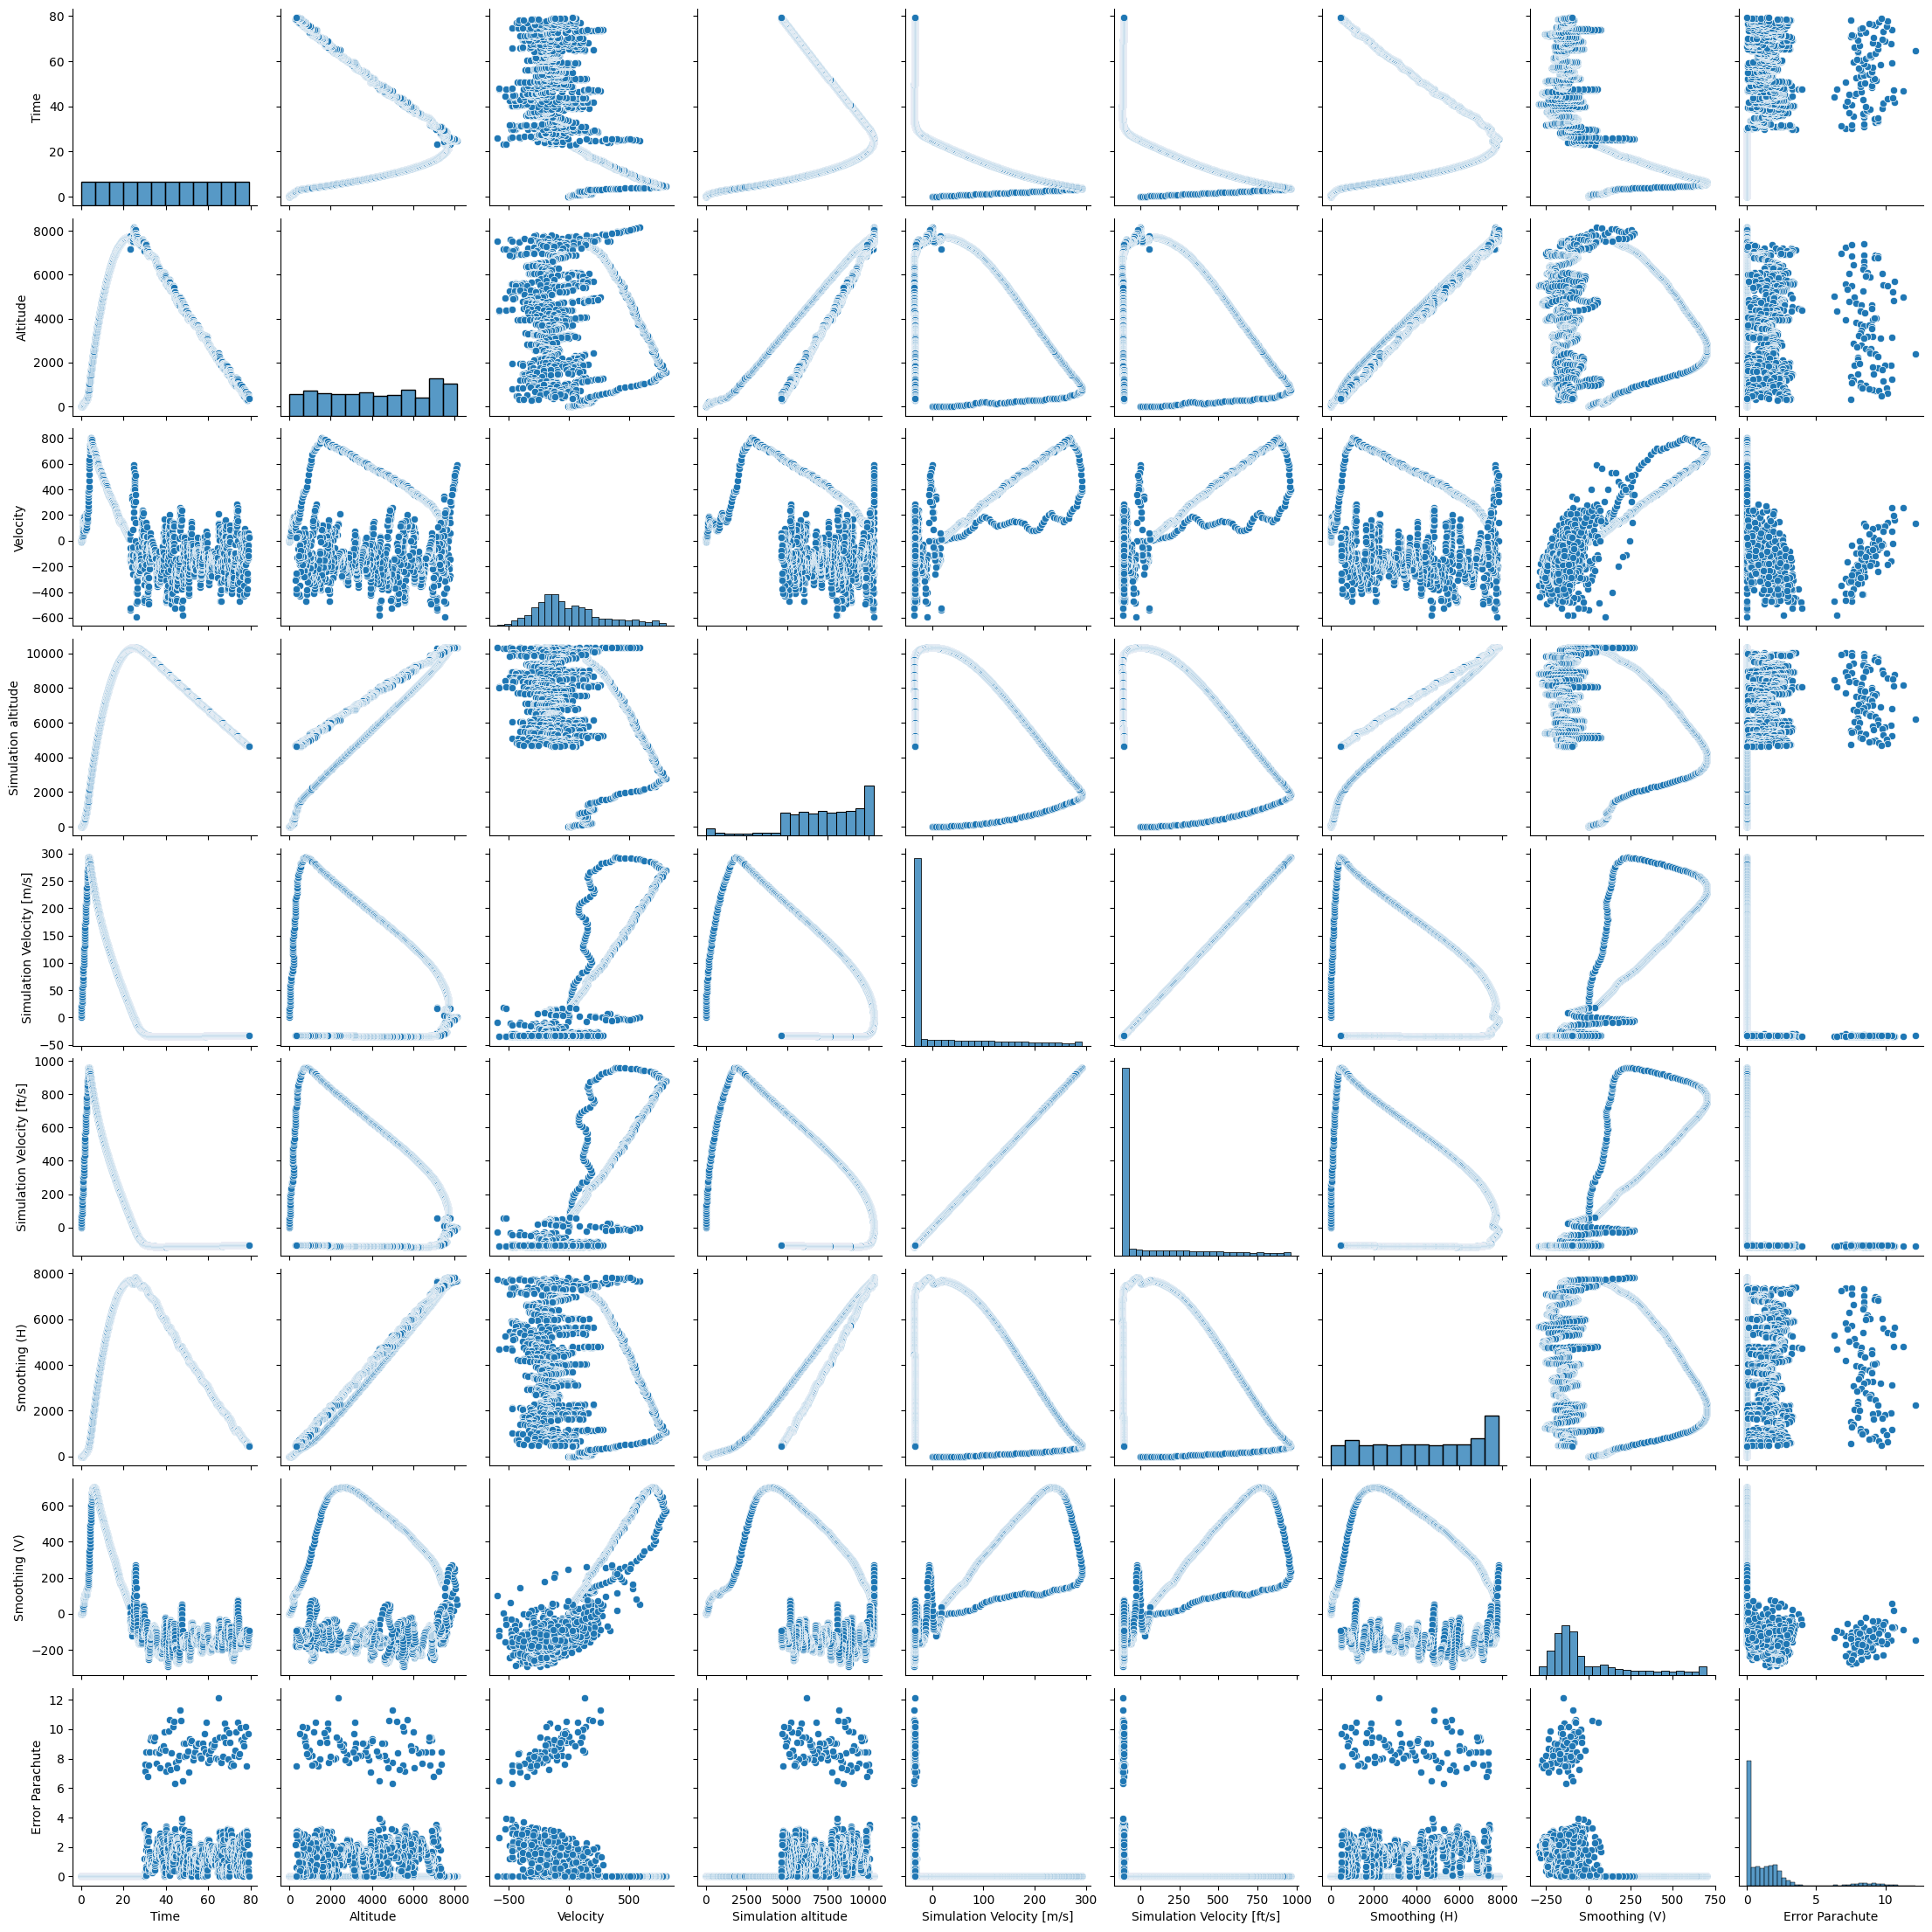

In [ ]:
sns.pairplot(df)